# Create the Blog Generator workflow

In [47]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [48]:
load_dotenv()

True

In [49]:
model = ChatOpenAI()

In [50]:
# model.invoke("what is the criteria for clearing the JEE Exam").content

In [51]:
# Create a State
class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    score: str

In [52]:
def get_gen_outline(state: BlogState) -> BlogState:
    # Get the title.
    title = state['title']

    # Prompt for the topic
    prompt = f'Give me the detailed report about {title}'

    # Get the answer
    answer = model.invoke(prompt).content

    # Update the state
    state['outline'] = answer

    # Return the state
    return state

In [53]:
def get_gen_blog(state: BlogState) ->  BlogState:
    # get the detailed outline of the topic.
    title = state['title']
    outline = state['outline']

    # Prompt for generating the blog
    prompt = f'Write a detailed blog on the title - {title} using the following outline \n {outline}'

    # Get the answer
    answer = model.invoke(prompt).content

    # Update the state
    state['content'] = answer

    # Return the state
    return state

In [54]:
def get_score(state: BlogState) -> BlogState:
    # get the score from the state.
    # score = state['score']
    content = state['content']
    outline = state['outline']

    # Prompt for generating the score.
    prompt = f"Evaluate my blog {content} based on the {outline} and return an integer score from 1 to 10 only."

    #Call the LLM.
    answer = model.invoke(prompt).content

    # Update the state
    state['score'] = answer

    # Return the state
    return state

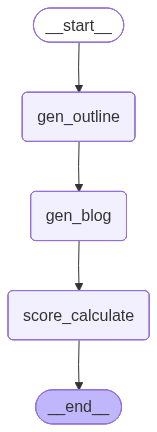

In [55]:
# Initialize the graph
graph = StateGraph(BlogState)


# Add nodes to the graph
graph.add_node('gen_outline', get_gen_outline)
graph.add_node('gen_blog', get_gen_blog)
graph.add_node('score_calculate', get_score)

# Add edges
graph.add_edge(START, 'gen_outline')
graph.add_edge('gen_outline', 'gen_blog')
graph.add_edge('gen_blog', 'score_calculate')
graph.add_edge('score_calculate', END)

# Compile the graph
graph.compile()

In [56]:
workflow = graph.compile()

In [57]:
# Execute the graph flow.

initial_state = {"title": "HFT Arbitrage"}


final_output = workflow.invoke(initial_state)

print(final_output['content'])


Despite the controversy surrounding HFT arbitrage, there are several advantages to this strategy. Firstly, HFT arbitrage provides liquidity to the market, ensuring that there are always buyers and sellers for financial instruments. This can help to reduce transaction costs for investors and improve market efficiency.

Additionally, HFT arbitrage can help to narrow bid-ask spreads, making it easier for investors to buy and sell assets at fair prices. By quickly identifying and exploiting price discrepancies, HFT arbitrage can also help to keep market prices in line with fundamental values.

Furthermore, HFT arbitrage can lead to improved price discovery and increased market efficiency. By quickly reacting to new information and price movements, HFT arbitrageurs can help to incorporate new information into asset prices more rapidly, allowing the market to more accurately reflect supply and demand dynamics.

In conclusion, HFT arbitrage is a high-speed trading strategy that involves capi

In [58]:
workflow.invoke(initial_state)

{'title': 'HFT Arbitrage',
 'outline': 'High Frequency Trading (HFT) Arbitrage is a strategy in which traders use advanced computer algorithms to exploit small price differences in financial assets across different markets. This strategy takes advantage of the high speed at which these algorithms can execute trades, allowing traders to capture profits in a matter of milliseconds.\n\nThere are several types of HFT arbitrage strategies, including:\n\n1. Statistical arbitrage: This strategy involves identifying patterns and correlations in asset prices and executing trades based on statistical models to profit from small price discrepancies.\n\n2. Market-making: Traders using this strategy place bids and offers in the market and profit from the spread between the buying and selling prices of an asset.\n\n3. Liquidity-providing arbitrage: This strategy involves taking advantage of differences in liquidity across different markets by buying assets where liquidity is high and selling them wh